In [ ]:
ASSIGNMENT 1
RAJ KAMAL PATNAIK
PNR - 240840143007


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn import datasets
from scipy.stats import norm
from scipy.integrate import simpson
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn import datasets

In [3]:
data_df = pd.read_csv('Dataset/boston_house_price.csv')

In [4]:
data_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [5]:
for col in data_df.columns:
    print(f'{col}: {data_df[col].unique()}\n')

CRIM: [6.32000e-03 2.73100e-02 2.72900e-02 3.23700e-02 6.90500e-02 2.98500e-02
 8.82900e-02 1.44550e-01 2.11240e-01 1.70040e-01 2.24890e-01 1.17470e-01
 9.37800e-02 6.29760e-01 6.37960e-01 6.27390e-01 1.05393e+00 7.84200e-01
 8.02710e-01 7.25800e-01 1.25179e+00 8.52040e-01 1.23247e+00 9.88430e-01
 7.50260e-01 8.40540e-01 6.71910e-01 9.55770e-01 7.72990e-01 1.00245e+00
 1.13081e+00 1.35472e+00 1.38799e+00 1.15172e+00 1.61282e+00 6.41700e-02
 9.74400e-02 8.01400e-02 1.75050e-01 2.76300e-02 3.35900e-02 1.27440e-01
 1.41500e-01 1.59360e-01 1.22690e-01 1.71420e-01 1.88360e-01 2.29270e-01
 2.53870e-01 2.19770e-01 8.87300e-02 4.33700e-02 5.36000e-02 4.98100e-02
 1.36000e-02 1.31100e-02 2.05500e-02 1.43200e-02 1.54450e-01 1.03280e-01
 1.49320e-01 1.71710e-01 1.10270e-01 1.26500e-01 1.95100e-02 3.58400e-02
 4.37900e-02 5.78900e-02 1.35540e-01 1.28160e-01 8.82600e-02 1.58760e-01
 9.16400e-02 1.95390e-01 7.89600e-02 9.51200e-02 1.01530e-01 8.70700e-02
 5.64600e-02 8.38700e-02 4.11300e-02 4.46200e

In [6]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


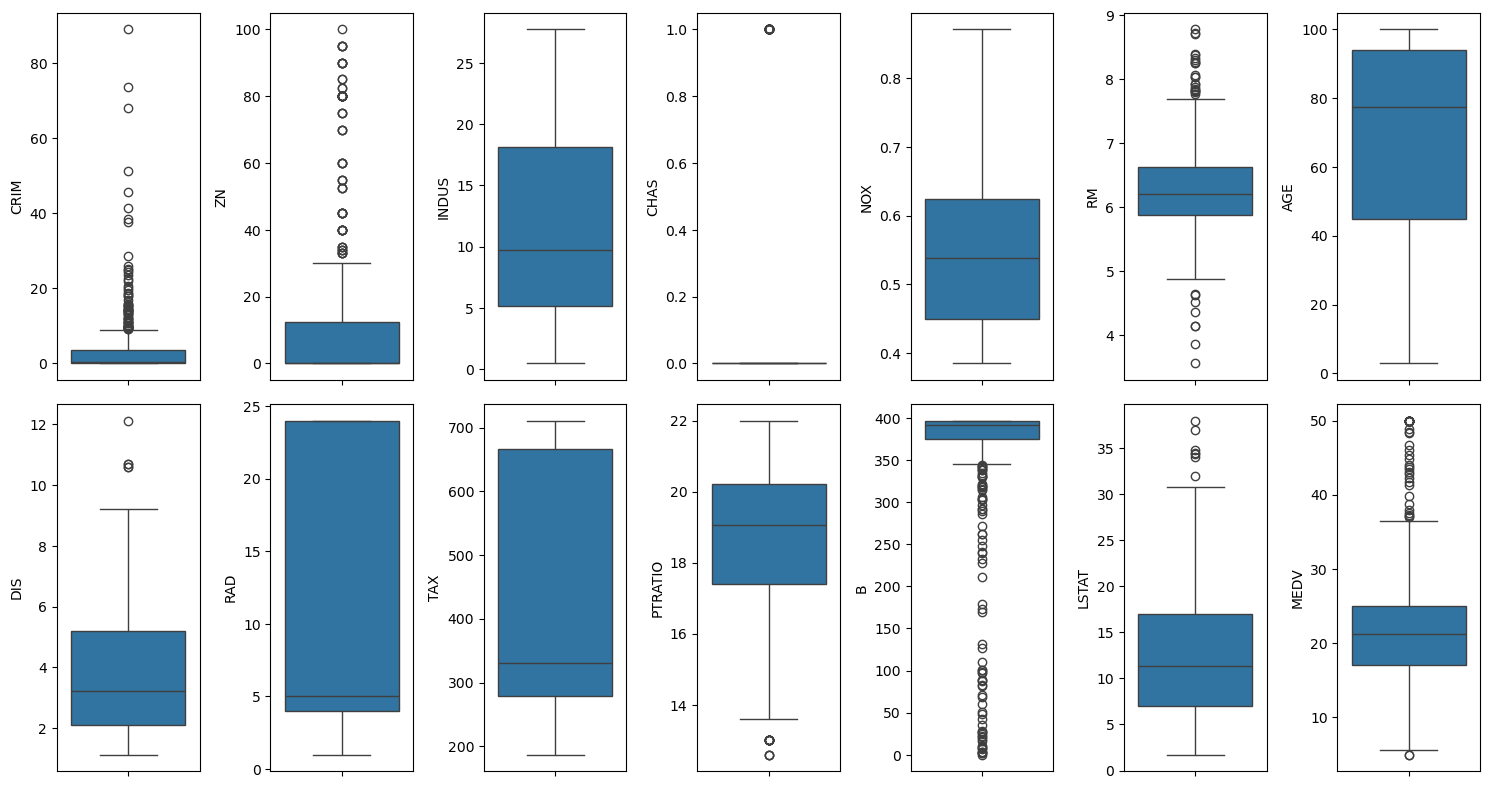

In [7]:
fig,axes = plt.subplots(2,7, figsize =(15,8))#preppare for plotting
axes = axes.ravel()#axes convrt from 1d to 2d
for count,col in enumerate(data_df.columns):
    ax= axes[count]
    sns.boxplot(data= data_df, y=col, ax=ax)

plt.tight_layout()

In [8]:
outlier_list = []
for count, col in enumerate(data_df.columns):
    Q1= np.percentile(data_df[col],25)
    Q3= np.percentile(data_df[col],75)
    IQR = Q3-Q1
    ol_dist= IQR*1.5
    outlier_list.extend(data_df[data_df[col]<Q1 - ol_dist].index)
    outlier_list.extend(data_df[data_df[col]>Q3 + ol_dist].index)

from collections import Counter
outlier_count = Counter(outlier_list)
outlier_count
    

Counter({412: 4,
         414: 4,
         283: 4,
         367: 3,
         374: 3,
         384: 3,
         438: 3,
         195: 3,
         203: 3,
         204: 3,
         162: 3,
         163: 3,
         257: 3,
         262: 3,
         267: 3,
         371: 2,
         373: 2,
         386: 2,
         387: 2,
         398: 2,
         399: 2,
         404: 2,
         405: 2,
         406: 2,
         407: 2,
         409: 2,
         410: 2,
         411: 2,
         413: 2,
         415: 2,
         416: 2,
         417: 2,
         418: 2,
         419: 2,
         420: 2,
         422: 2,
         425: 2,
         426: 2,
         427: 2,
         429: 2,
         431: 2,
         434: 2,
         435: 2,
         436: 2,
         437: 2,
         444: 2,
         445: 2,
         454: 2,
         190: 2,
         196: 2,
         197: 2,
         198: 2,
         202: 2,
         256: 2,
         274: 2,
         276: 2,
         277: 2,
         286: 2,
         291: 

In [9]:
data_df.iloc[[412,414,283]]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
412,18.81100,0.0,18.10,0.0,0.597,4.628,100.0,1.5539,24.0,666.0,20.2,28.79,34.37,17.9
414,45.74610,0.0,18.10,0.0,0.693,4.519,100.0,1.6582,24.0,666.0,20.2,88.27,36.98,7.0
283,0.01501,90.0,1.21,1.0,0.401,7.923,24.8,5.8850,1.0,198.0,13.6,395.52,3.16,50.0


In [10]:
data_df = data_df.drop([412,414,283], axis=0 ).copy()
data_df = data_df[data_df['MEDV']<50].copy()
data_df.reset_index(inplace=True, drop=True)
data_df.shape

(488, 14)

<Axes: >

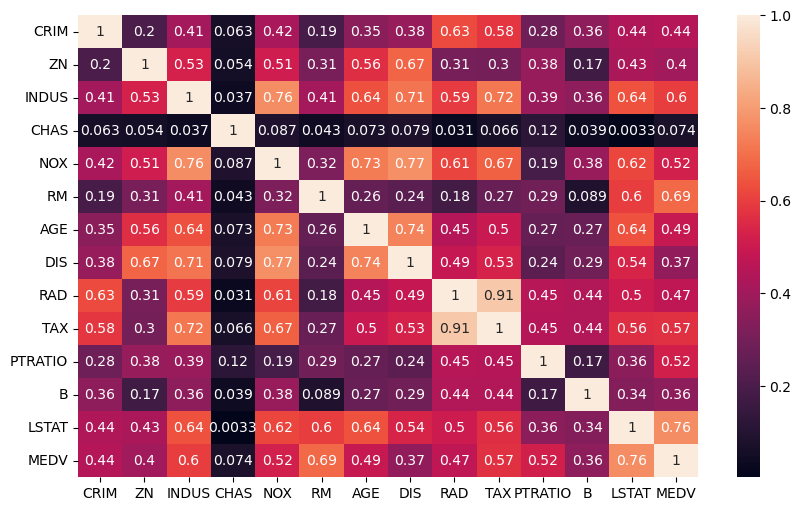

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(data_df.corr().abs(), annot=True)

In [12]:
colums_sels=['LSTAT','INDUS','NOX','PTRATIO','RM','TAX']

scaler = MinMaxScaler()

features = data_df[colums_sels].copy()

target = data_df['MEDV']

In [13]:
features = pd.DataFrame(data=scaler.fit_transform(features),
                       columns=colums_sels)
features.head()

,LSTAT,INDUS,NOX,PTRATIO,RM,TAX
0,0.083356,0.058148,0.314815,0.287234,0.577505,0.208015
1,0.198944,0.234444,0.172840,0.553191,0.547998,0.104962
2,0.056960,0.234444,0.172840,0.553191,0.694386,0.104962
3,0.026674,0.053333,0.150206,0.648936,0.658555,0.066794
4,0.093081,0.053333,0.150206,0.648936,0.687105,0.066794


In [14]:
reg = LinearRegression()

reg.fit(features, target)

y_pred = reg.predict(features)

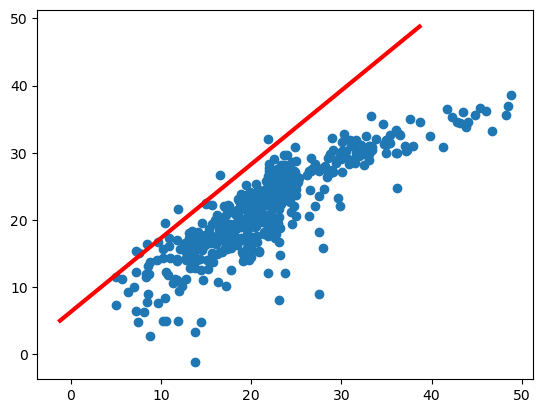

In [15]:
plt.scatter(target, y_pred)
plt.plot([y_pred.min(), y_pred.max()], [target.min(), target.max()], c='r', lw=3)

TEST 2

In [16]:
mean_squared_error(y_pred=y_pred, y_true =target)

16.137851951377435

In [17]:
colums_sels=['LSTAT','INDUS','NOX','PTRATIO','RM','TAX','AGE','NOX']

scaler = MinMaxScaler()

features = data_df[colums_sels].copy()

target = data_df['NOX']

In [18]:
features = pd.DataFrame(data=scaler.fit_transform(features),
                       columns=colums_sels)
features.head()

,LSTAT,INDUS,NOX,PTRATIO,RM,TAX,AGE,NOX
0,0.083356,0.058148,0.314815,0.287234,0.577505,0.208015,0.641607,0.314815
1,0.198944,0.234444,0.172840,0.553191,0.547998,0.104962,0.782698,0.172840
2,0.056960,0.234444,0.172840,0.553191,0.694386,0.104962,0.599382,0.172840
3,0.026674,0.053333,0.150206,0.648936,0.658555,0.066794,0.441813,0.150206
4,0.093081,0.053333,0.150206,0.648936,0.687105,0.066794,0.528321,0.150206


In [19]:
reg = LinearRegression()

reg.fit(features, target)

y_pred = reg.predict(features)

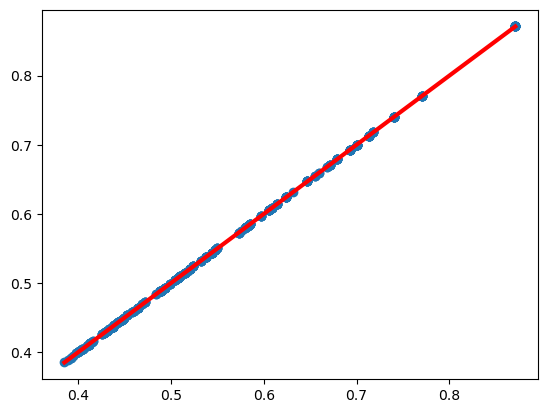

In [20]:
plt.scatter(target, y_pred)
plt.plot([y_pred.min(), y_pred.max()], [target.min(), target.max()], c='r', lw=3)

Test 3

In [21]:
mean_squared_error(y_pred=y_pred, y_true =target)

6.3839841763131e-33

In [22]:
colums_sels=['LSTAT','INDUS','NOX','PTRATIO','RM','TAX','AGE','NOX']

scaler = MinMaxScaler()

features = data_df[colums_sels].copy()

target = data_df['CHAS']

In [23]:
features = pd.DataFrame(data=scaler.fit_transform(features),
                       columns=colums_sels)
features.head()

,LSTAT,INDUS,NOX,PTRATIO,RM,TAX,AGE,NOX
0,0.083356,0.058148,0.314815,0.287234,0.577505,0.208015,0.641607,0.314815
1,0.198944,0.234444,0.172840,0.553191,0.547998,0.104962,0.782698,0.172840
2,0.056960,0.234444,0.172840,0.553191,0.694386,0.104962,0.599382,0.172840
3,0.026674,0.053333,0.150206,0.648936,0.658555,0.066794,0.441813,0.150206
4,0.093081,0.053333,0.150206,0.648936,0.687105,0.066794,0.528321,0.150206


In [24]:
reg = LinearRegression()

reg.fit(features, target)

y_pred = reg.predict(features)

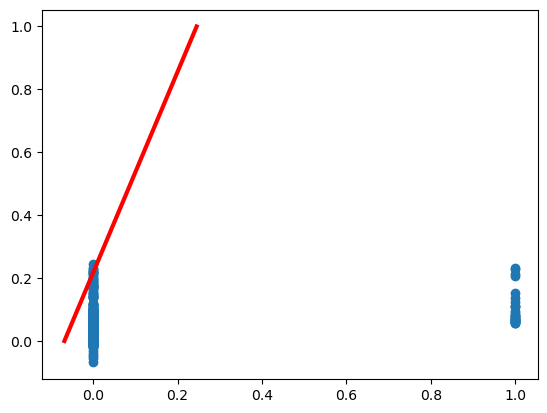

In [25]:
plt.scatter(target, y_pred)
plt.plot([y_pred.min(), y_pred.max()], [target.min(), target.max()], c='r', lw=3)

test 4

In [26]:
mean_squared_error(y_pred=y_pred, y_true =target)

0.05332825971555607

In [27]:
colums_sels=['LSTAT','INDUS','NOX','RM','TAX','AGE','NOX']

scaler = MinMaxScaler()

features = data_df[colums_sels].copy()

target = data_df['PTRATIO']

In [28]:
features = pd.DataFrame(data=scaler.fit_transform(features),
                       columns=colums_sels)
features.head()

,LSTAT,INDUS,NOX,RM,TAX,AGE,NOX
0,0.083356,0.058148,0.314815,0.577505,0.208015,0.641607,0.314815
1,0.198944,0.234444,0.172840,0.547998,0.104962,0.782698,0.172840
2,0.056960,0.234444,0.172840,0.694386,0.104962,0.599382,0.172840
3,0.026674,0.053333,0.150206,0.658555,0.066794,0.441813,0.150206
4,0.093081,0.053333,0.150206,0.687105,0.066794,0.528321,0.150206


In [29]:
reg = LinearRegression()

reg.fit(features, target)

y_pred = reg.predict(features)

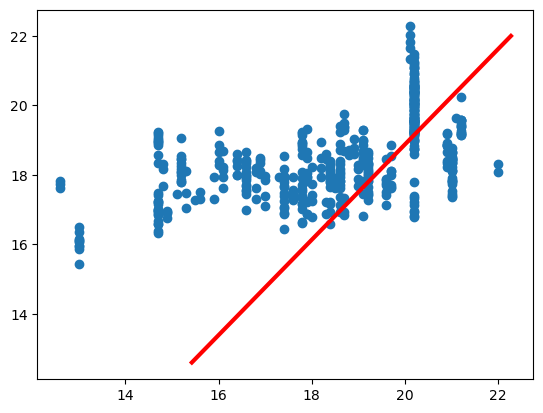

In [30]:
plt.scatter(target, y_pred)
plt.plot([y_pred.min(), y_pred.max()], [target.min(), target.max()], c='r', lw=3)

In [31]:
mean_squared_error(y_pred=y_pred, y_true =target)

3.0423329064796487

<Axes: >

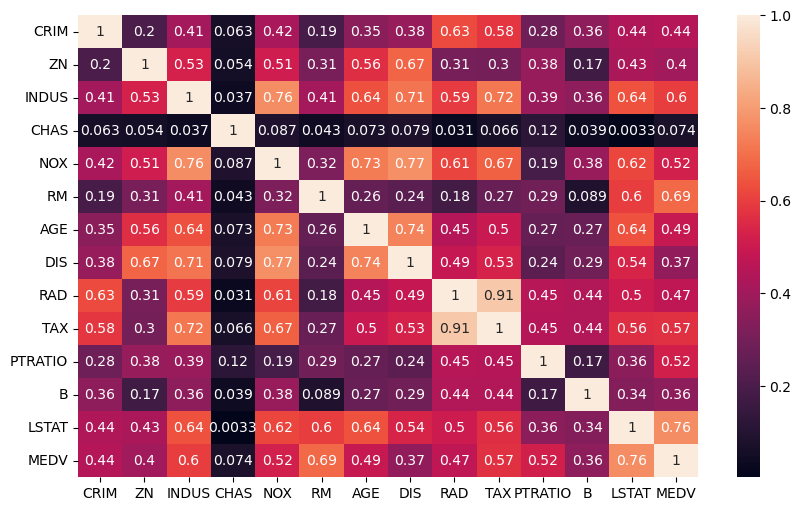

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(data_df.corr().abs(), annot=True)

In [33]:
colums_sels=['CRIM','INDUS','NOX','AGE','RAD','PTRATIO','LSTAT']

scaler = MinMaxScaler()

features = data_df[colums_sels].copy()

target = data_df['B']

In [34]:
features = pd.DataFrame(data=scaler.fit_transform(features),
                       columns=colums_sels)
features.head()

,CRIM,INDUS,NOX,AGE,RAD,PTRATIO,LSTAT
0,0.000000,0.058148,0.314815,0.641607,0.000000,0.287234,0.083356
1,0.000236,0.234444,0.172840,0.782698,0.043478,0.553191,0.198944
2,0.000236,0.234444,0.172840,0.599382,0.043478,0.553191,0.056960
3,0.000293,0.053333,0.150206,0.441813,0.086957,0.648936,0.026674
4,0.000705,0.053333,0.150206,0.528321,0.086957,0.648936,0.093081


In [35]:
reg = LinearRegression()

reg.fit(features, target)

y_pred = reg.predict(features)

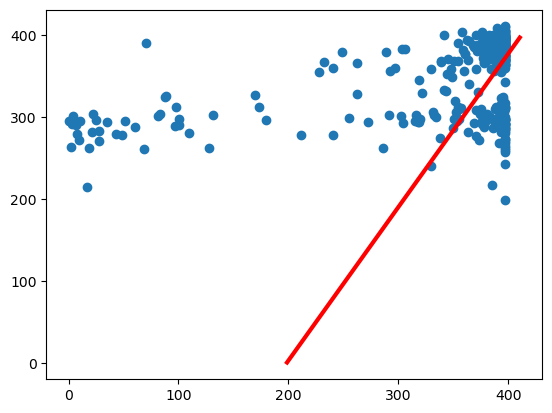

In [36]:
plt.scatter(target, y_pred)
plt.plot([y_pred.min(), y_pred.max()], [target.min(), target.max()], c='r', lw=3)

In [37]:
mean_squared_error(y_pred=y_pred, y_true =target)

6316.001257375443

In [38]:
colums_sels=['CRIM','INDUS','NOX','AGE','RAD','PTRATIO','LSTAT','ZN','CHAS','RM','DIS','TAX','B','MEDV']

scaler = MinMaxScaler()

features = data_df[colums_sels].copy()

target = data_df['CRIM']

In [39]:
features = pd.DataFrame(data=scaler.fit_transform(features),
                       columns=colums_sels)
features.head()

,CRIM,INDUS,NOX,AGE,RAD,PTRATIO,LSTAT,ZN,CHAS,RM,DIS,TAX,B,MEDV
0,0.000000,0.058148,0.314815,0.641607,0.000000,0.287234,0.083356,0.18,0.0,0.577505,0.268711,0.208015,1.000000,0.433790
1,0.000236,0.234444,0.172840,0.782698,0.043478,0.553191,0.198944,0.00,0.0,0.547998,0.348524,0.104962,1.000000,0.378995
2,0.000236,0.234444,0.172840,0.599382,0.043478,0.553191,0.056960,0.00,0.0,0.694386,0.348524,0.104962,0.989737,0.678082
3,0.000293,0.053333,0.150206,0.441813,0.086957,0.648936,0.026674,0.00,0.0,0.658555,0.448173,0.066794,0.994276,0.648402
4,0.000705,0.053333,0.150206,0.528321,0.086957,0.648936,0.093081,0.00,0.0,0.687105,0.448173,0.066794,1.000000,0.712329


In [40]:
reg = LinearRegression()

reg.fit(features, target)

y_pred = reg.predict(features)

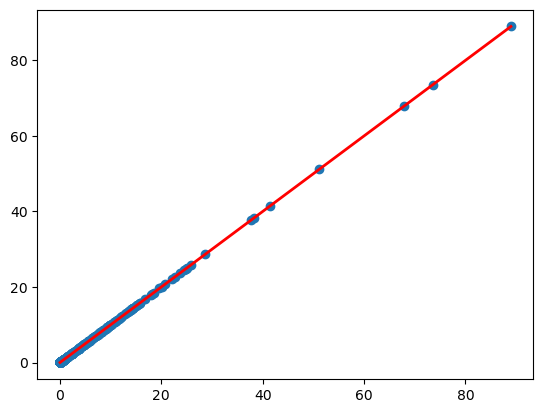

In [41]:
plt.scatter(target, y_pred)
plt.plot([y_pred.min(), y_pred.max()], [target.min(), target.max()], c='r', lw=2)

In [42]:
mean_squared_error(y_pred=y_pred, y_true =target)

2.647436679018829e-29

In [43]:
colums_sels=['CRIM','INDUS','RAD','PTRATIO','LSTAT','ZN','CHAS','RM','DIS','TAX','B','MEDV']

scaler = MinMaxScaler()

features = data_df[colums_sels].copy()

target = data_df['MEDV']

In [44]:
features = pd.DataFrame(data=scaler.fit_transform(features),
                       columns=colums_sels)
features.head()

,CRIM,INDUS,RAD,PTRATIO,LSTAT,ZN,CHAS,RM,DIS,TAX,B,MEDV
0,0.000000,0.058148,0.000000,0.287234,0.083356,0.18,0.0,0.577505,0.268711,0.208015,1.000000,0.433790
1,0.000236,0.234444,0.043478,0.553191,0.198944,0.00,0.0,0.547998,0.348524,0.104962,1.000000,0.378995
2,0.000236,0.234444,0.043478,0.553191,0.056960,0.00,0.0,0.694386,0.348524,0.104962,0.989737,0.678082
3,0.000293,0.053333,0.086957,0.648936,0.026674,0.00,0.0,0.658555,0.448173,0.066794,0.994276,0.648402
4,0.000705,0.053333,0.086957,0.648936,0.093081,0.00,0.0,0.687105,0.448173,0.066794,1.000000,0.712329


In [45]:
reg = LinearRegression()

reg.fit(features, target)

y_pred = reg.predict(features)

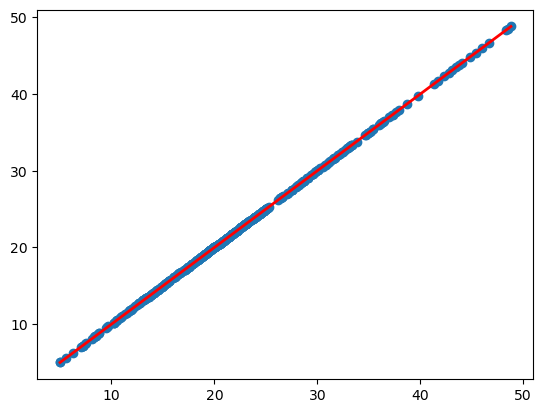

In [46]:
plt.scatter(target, y_pred)
plt.plot([y_pred.min(), y_pred.max()], [target.min(), target.max()], c='r', lw=2)

In [47]:
mean_squared_error(y_pred=y_pred, y_true =target)

7.968303401856422e-29

<Figure size 600x400 with 0 Axes>

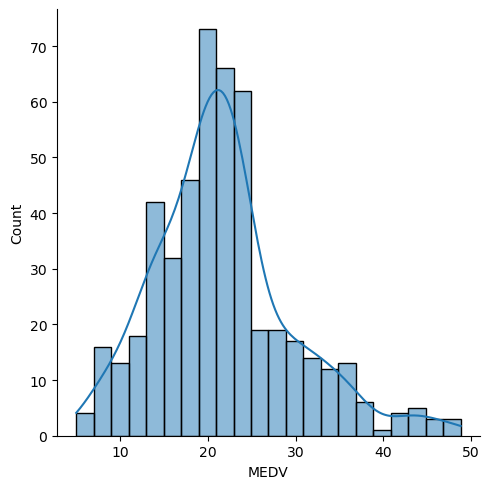

In [48]:
plt.figure(figsize=(6,4))
sns.displot(data=data_df, x='MEDV', kde=True)

In [49]:
y = np.log1p(data_df['MEDV'])
y

0      3.218876
1      3.117950
2      3.575151
3      3.538057
4      3.616309
         ...   
483    3.152736
484    3.072693
485    3.214868
486    3.135494
487    2.557227
Name: MEDV, Length: 488, dtype: float64

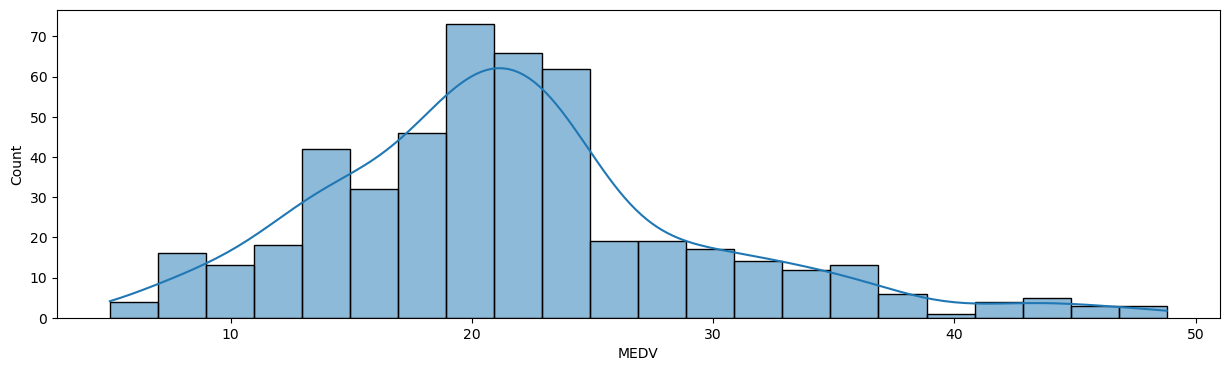

In [50]:
fig, ax = plt.subplots(figsize=(15,4))
sns.histplot(data=data_df , x='MEDV', kde=True, ax=ax);

In [51]:
y = np.log1p(data_df['MEDV']) # 1p avoids log(0)
data_df['log_val']=y


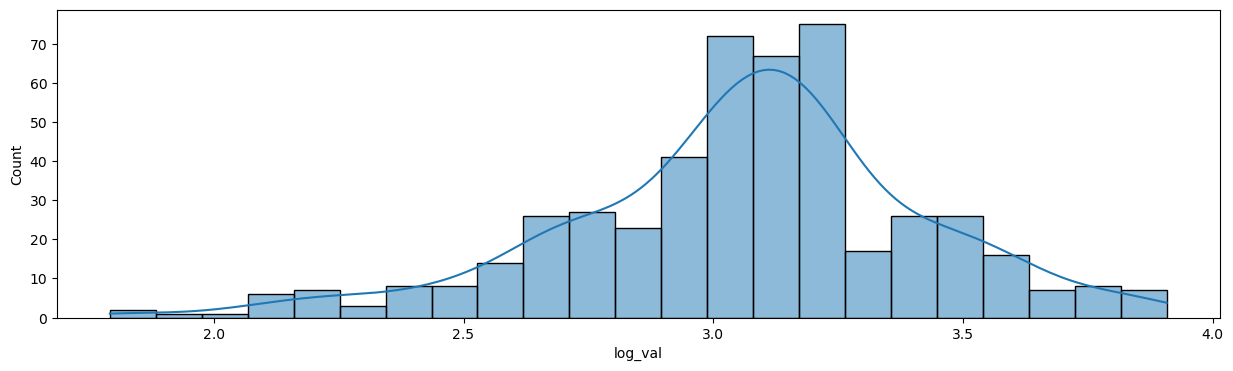

In [52]:
fig, ax = plt.subplots(figsize=(15,4))
sns.histplot(data=data_df , x='log_val', kde=True, ax=ax);

## Logistic Regression

### Case 1 :   Binary Classification

In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn import datasets
from scipy.stats import norm
from scipy.integrate import simpson
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn import datasets

In [55]:
RANDOM_STATE = 24
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results

NOISE = 0.1
N_SAMPLES = 1000


# parameters for Matplotlib
params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 5),
          'axes.labelsize': 'large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'large',
          'ytick.labelsize':'large',
          'savefig.dpi': 75,
          'image.interpolation': 'none',
          'savefig.bbox' : 'tight',
          'lines.linewidth' : 1,
          'legend.numpoints' : 1
         }
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
X, y = datasets.make_moons(n_samples=N_SAMPLES,
                           noise=NOISE,
                           random_state=RANDOM_STATE)

In [57]:
X[:5], y[:5]

(array([[ 0.79254123,  0.81852609],
        [-0.86341583,  0.77353281],
        [ 1.94098477,  0.40538635],
        [-0.96149236,  0.06064943],
        [-0.98373033,  0.05715389]]),
 array([0, 0, 1, 0, 0], dtype=int64))

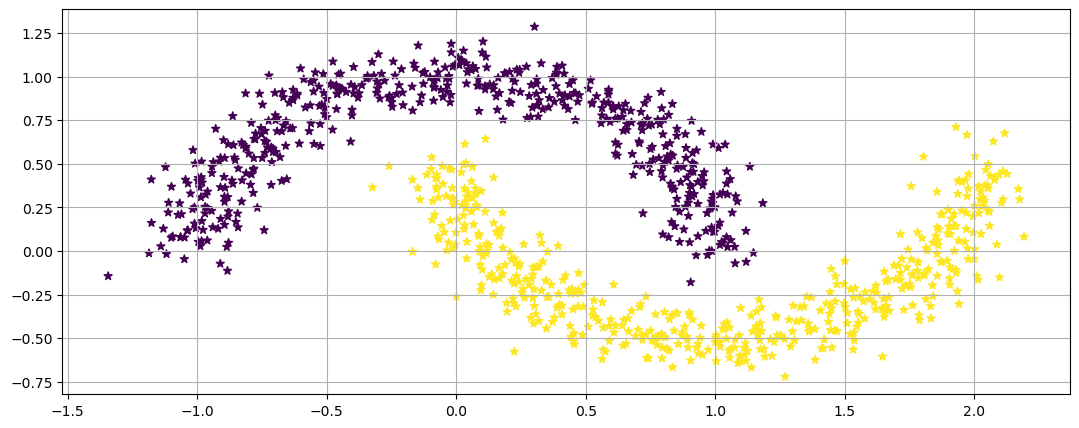

In [58]:
plt.figure(figsize=(13,5))
plt.scatter(X[:,0], X[:,1], marker = '*', c=y)
plt.grid(True)

In [59]:
clf= LogisticRegression(penalty = None,
                       random_state=RANDOM_STATE)
clf.fit(X,y)
y_pred = clf.predict(X)

In [60]:
y_pred

array([0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,

In [61]:
clf.predict_proba(X[:2, :])

array([[0.95143545, 0.04856455],
       [0.99034282, 0.00965718]])

In [62]:
y_pred[:2]

array([0, 0], dtype=int64)

### Decision Boundary

In [64]:
def fn_plot_decision_boundary(X):

    fig, ax=plt.subplots(figsize=(15,5))

    dm = 0.01

    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5 # Col 2

    y_min, y_max = X[:,0].min()-0.5, X[:,1].max()+0.5 # Col 1

    # Create a meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm),
                         np.arange(y_min, y_max, dm))

    return xx, yy

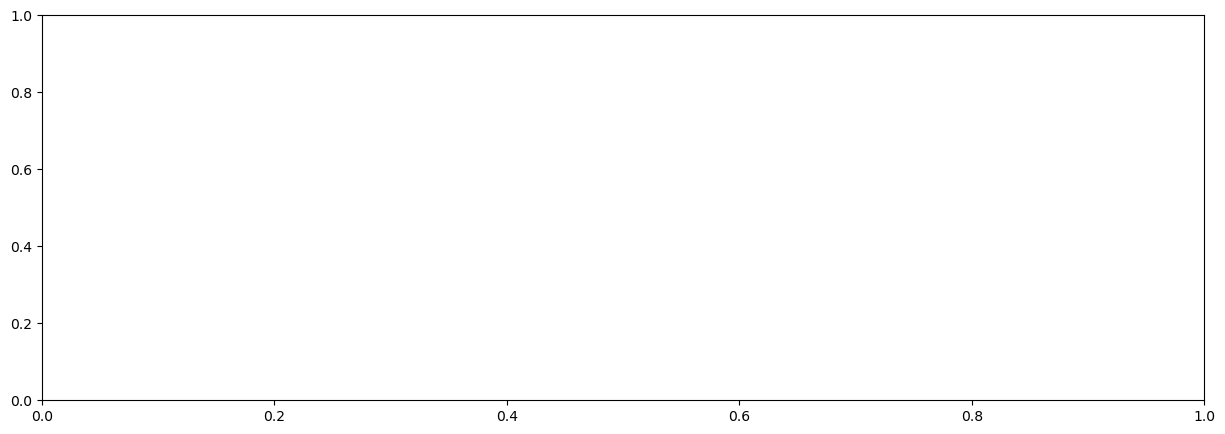

In [65]:
xx, yy = fn_plot_decision_boundary(X)

In [66]:
xx, yy = xx.ravel(), yy.ravel()
xx.shape, yy.shape

((164802,), (164802,))

In [67]:
plt.figure(figsize=(100,100))
plt.scatter(xx, yy, marker = '+')

In [68]:
X

array([[ 0.79254123,  0.81852609],
       [-0.86341583,  0.77353281],
       [ 1.94098477,  0.40538635],
       ...,
       [ 0.31950406,  0.86437406],
       [ 1.76039532, -0.13329496],
       [-0.91576933,  0.51324915]])

In [69]:
def fn_plot_decision_boundary(X):

    fig, ax=plt.subplots(figsize=(15,5))

    dm = 0.01

    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5 # Col 2

    y_min, y_max = X[:,0].min()-0.5, X[:,1].max()+0.5 # Col 1

    # Create a meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm),
                         np.arange(y_min, y_max, dm))

    # Stack them
    XX = np.c_[xx.ravel(), yy.ravel()]

    # Make Predictions
    y_pred = clf.predict(XX)

    # Assign predictions to be respect point
    Z = y_pred.reshape(xx.shape)
    
    return

In [70]:
def fn_plot_decision_boundary(X):

    fig, ax=plt.subplots(figsize=(15,5))

    dm = 0.01

    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5 # Col 2

    y_min, y_max = X[:,0].min()-0.5, X[:,1].max()+0.5 # Col 1

    # Create a meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm),
                         np.arange(y_min, y_max, dm))

    # Stack them
    XX = np.c_[xx.ravel(), yy.ravel()]

    # Make Predictions
    y_pred = clf.predict(XX)

    # Assign predictions to be respect point
    Z = y_pred.reshape(xx.shape)

    ax.contourf(xx,yy, Z, aplpha=0.6, cmap=plt.cm.Paired)
    
    return

C:\Users\duasp\AppData\Local\Temp\ipykernel_13560\3387464578.py:24: UserWarning: The following kwargs were not used by contour: 'aplpha'
  ax.contourf(xx,yy, Z, aplpha=0.6, cmap=plt.cm.Paired)


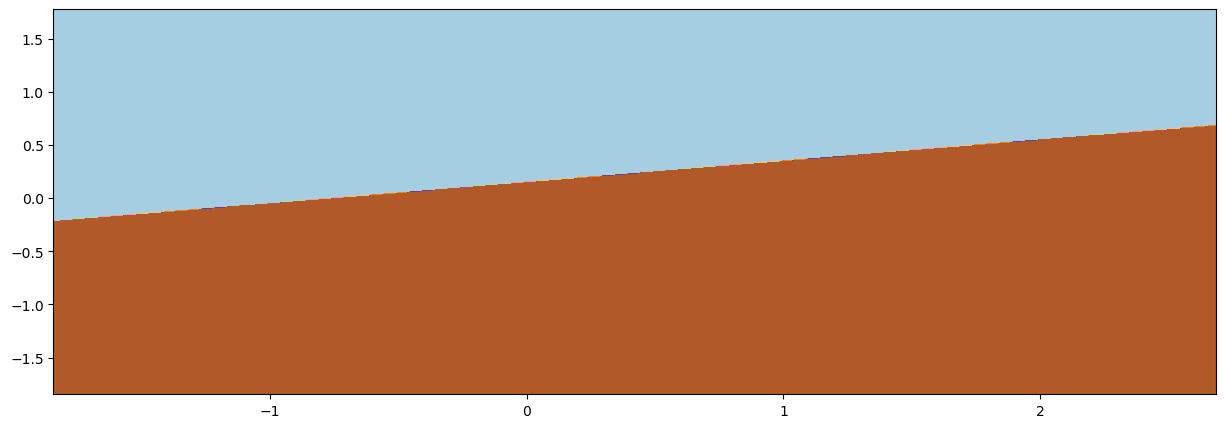

In [71]:
fn_plot_decision_boundary(X)

In [72]:
def fn_plot_decision_boundary(X1, y, clf):
    '''
    Args:
        X1: np.ndarray - Feature matrix
        y : np.ndarray - labels/targets
        clf: classifier
    '''
    fig, ax=plt.subplots(figsize=(15,5))

    dm = 0.01

    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5 # Col 2

    y_min, y_max = X[:,0].min()-0.5, X[:,1].max()+0.5 # Col 1

    # Create a meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm),
                         np.arange(y_min, y_max, dm))

    # Stack them
    XX = np.c_[xx.ravel(), yy.ravel()]

    # Make Predictions
    y_pred = clf.predict(XX)

    # Assign predictions to be respect point
    Z = y_pred.reshape(xx.shape)

    ax.contourf(xx,yy, Z, aplpha=0.6, cmap=plt.cm.Paired)
    ax.scatter(X1[:,0], X1[:,1], c=y, marker='*', edgecolor='black')
    return

C:\Users\duasp\AppData\Local\Temp\ipykernel_13560\860674418.py:29: UserWarning: The following kwargs were not used by contour: 'aplpha'
  ax.contourf(xx,yy, Z, aplpha=0.6, cmap=plt.cm.Paired)


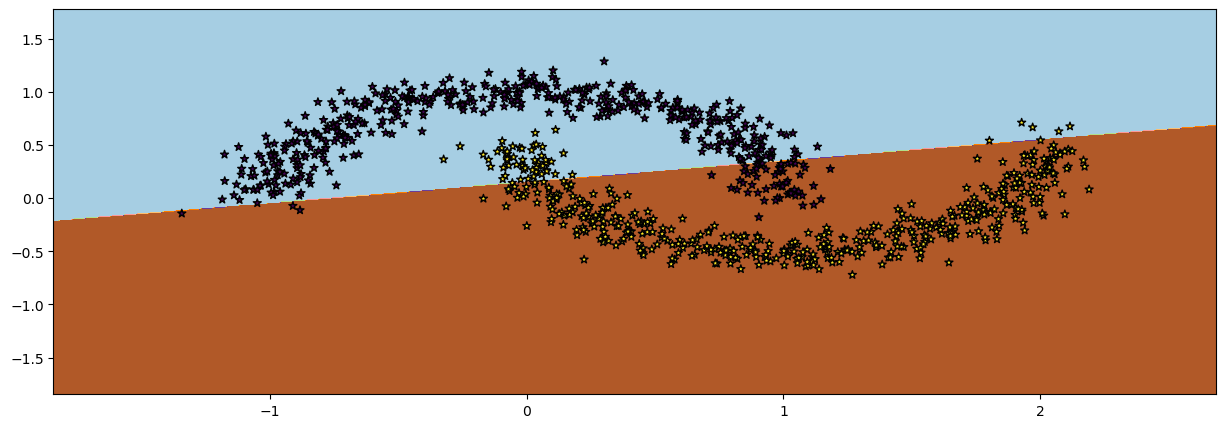

In [73]:
fn_plot_decision_boundary(X, y, clf)

## ONE VS REST

In [75]:
X, y = datasets.load_iris(return_X_y=True)

In [76]:
label_names = {0: 'setosa', 1:'versicolor', 2:'virginica'}
X.shape, y.shape

((150, 4), (150,))

In [77]:
from sklearn.multiclass import OneVsRestClassifier
clf = LogisticRegression(penalty=None,
                        multi_class='ovr',
                        random_state=RANDOM_STATE)

clf.fit(X,y)
y_pred = clf.predict(X)

x_err= X[:,0][y!=y_pred]
y_err=X[:,1][y!=y_pred]
x_err.shape, y_err.shape



((3,), (3,))

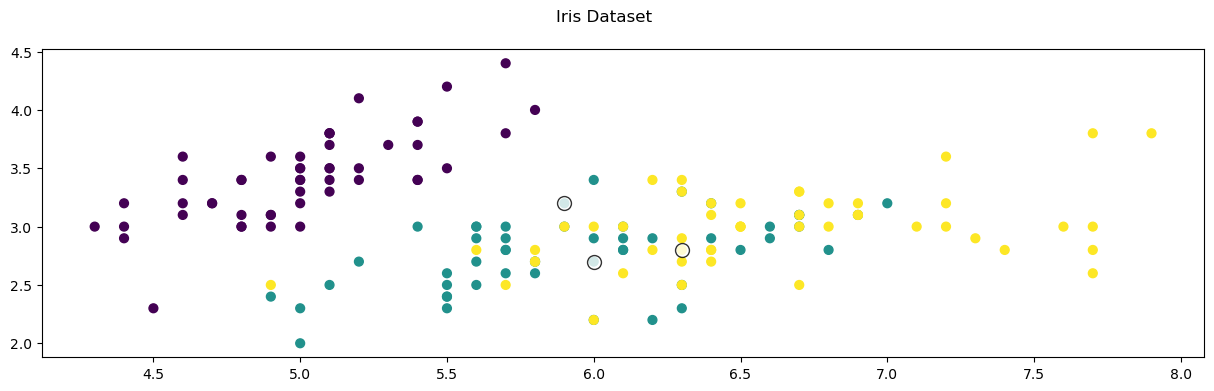

In [78]:
fig, ax = plt.subplots(figsize=(15,4))
title='Iris Dataset'
fig.suptitle(title)

ax.scatter(X[:,0], X[:,1], s=40, c=y)
ax.scatter(x_err, y_err,
          color='w',
           s=100,
          alpha=0.8,
          edgecolor='k')

In [79]:
# from sklearn.multiclass import OneVsRestClassifier
clf = LogisticRegression(penalty=None,
                        multi_class='multinomial',
                        random_state=RANDOM_STATE)

clf.fit(X,y)
y_pred = clf.predict(X)

x_err= X[:,0][y!=y_pred]
y_err=X[:,1][y!=y_pred]
x_err.shape, y_err.shape


((2,), (2,))

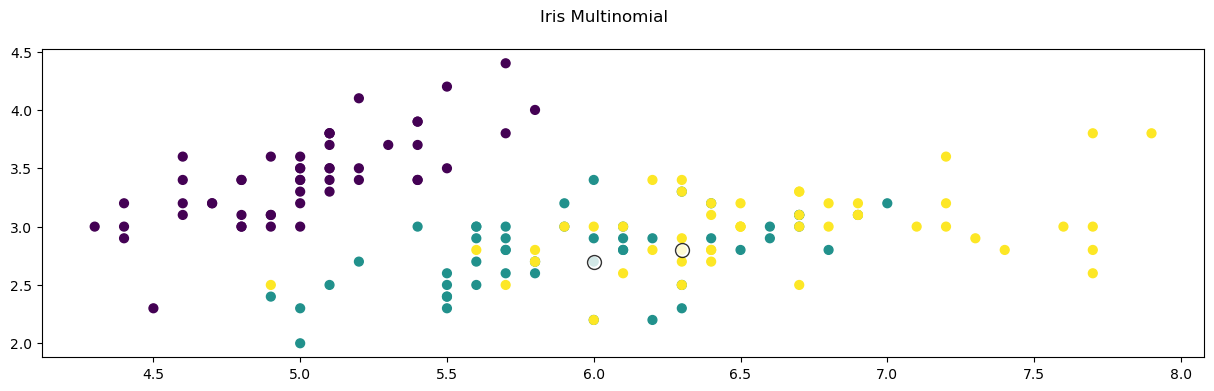

In [80]:
fig, ax = plt.subplots(figsize=(15,4))
title='Iris Multinomial'
fig.suptitle(title)

ax.scatter(X[:,0], X[:,1], s=40, c=y)
ax.scatter(x_err, y_err,
          color='w',
           s=100,
          alpha=0.8,
          edgecolor='k')